In [6]:
import torch
# dinov2_vitl14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
dinov2_vitl14 = torch.hub.load(
    repo_or_dir="/home/baai/.cache/torch/hub/facebookresearch_dinov2_main",
    model="dinov2_vitl14", # 自定义模型
    trust_repo=True, # 本地权重文件路径
    source="local" # 从本地加载模型权重
)  

Processing: ./test_images/000000_lcam_back.png
Original image size: 640x640
Adjusted size (divisible by 14): 630x630
Input tensor shape: torch.Size([1, 3, 630, 630])
Patch features shape: torch.Size([1, 2025, 1024])
Spatial dimensions: 45x45 = 2025
PCA explained variance ratio: [0.11667533 0.09732643 0.06914383]


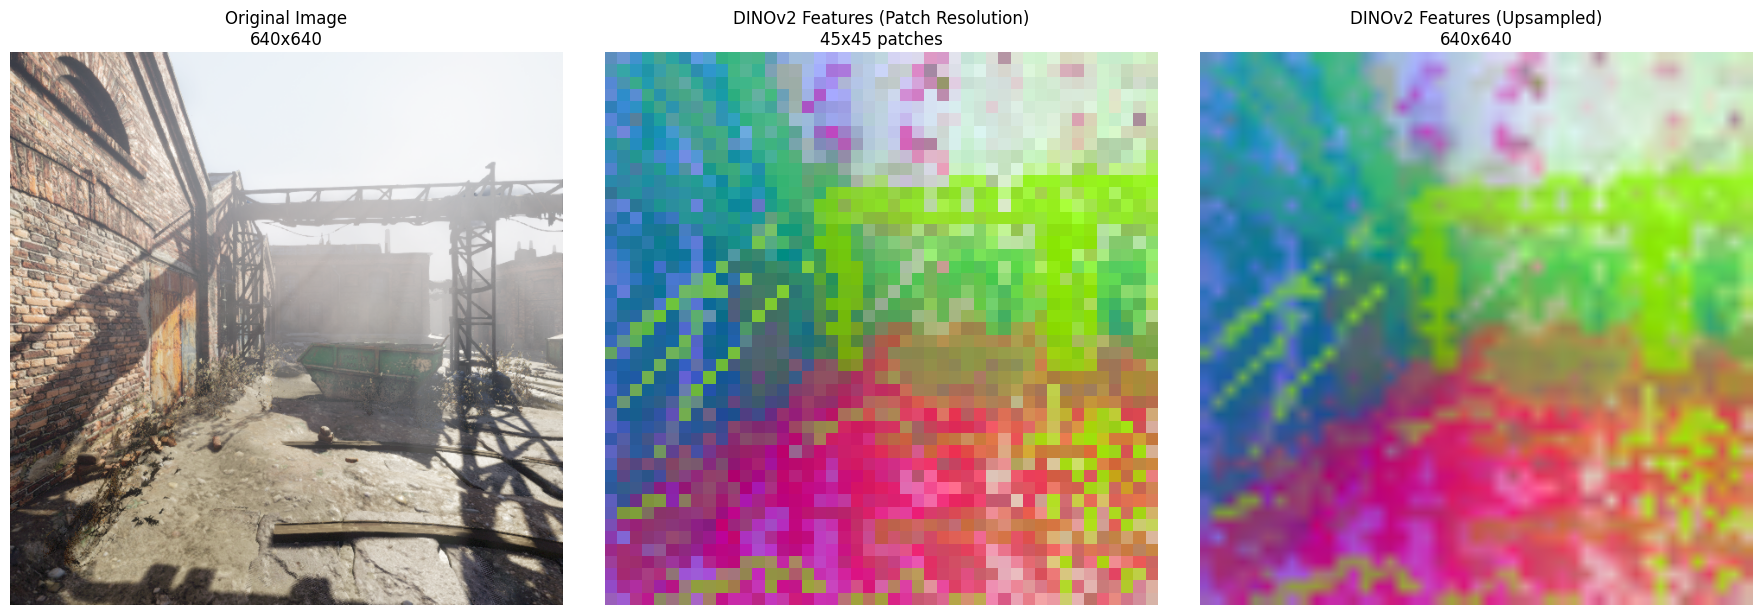


Visualization complete!
Each patch represents a 14x14 region from the input image


In [ ]:
# Extract per-patch features from DINOv2 and visualize with PCA
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch.nn.functional as F

# Load a single image for patch feature extraction
img_path = "./test_images"  # Change this to your image path
img_files = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
    import glob
    img_files.extend(glob.glob(os.path.join(img_path, ext)))

if not img_files:
    print("No images found. Please add images to ./test_images")
else:
    # Use the first image
    img_file = img_files[0]
    print(f"Processing: {img_file}")
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = dinov2_vitl14.to(device).eval()
    
    # Load original image
    img = Image.open(img_file).convert("RGB")
    orig_w, orig_h = img.size
    print(f"Original image size: {orig_w}x{orig_h}")
    
    # DINOv2 ViT-L/14: patch_size=14
    patch_size = 14
    
    # 调整尺寸到能被 patch_size 整除（保持原始宽高比）
    new_h = (orig_h // patch_size) * patch_size
    new_w = (orig_w // patch_size) * patch_size
    
    # 如果尺寸为0，至少保证一个 patch
    if new_h == 0:
        new_h = patch_size
    if new_w == 0:
        new_w = patch_size
    
    print(f"Adjusted size (divisible by {patch_size}): {new_w}x{new_h}")
    
    transform = T.Compose([
        T.Resize((new_h, new_w)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    print(f"Input tensor shape: {img_tensor.shape}")
    
    # Extract patch features
    with torch.no_grad():
        patch_features = model.get_intermediate_layers(img_tensor, n=1)[0]
        # patch_features shape: [1, num_patches, feature_dim]
    
    # Get dimensions
    batch_size, num_patches, feature_dim = patch_features.shape
    patch_h = new_h // patch_size
    patch_w = new_w // patch_size
    
    print(f"Patch features shape: {patch_features.shape}")
    print(f"Spatial dimensions: {patch_h}x{patch_w} = {patch_h * patch_w}")
    
    # Reshape to [num_patches, feature_dim] for PCA
    patch_features_np = patch_features[0].cpu().numpy()
    
    # Apply PCA to reduce to 3 dimensions (RGB)
    pca = PCA(n_components=3, random_state=0)
    pca_features = pca.fit_transform(patch_features_np)
    
    print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
    
    # Normalize to [0, 1] for RGB visualization
    pca_min = pca_features.min(axis=0)
    pca_max = pca_features.max(axis=0)
    pca_normalized = (pca_features - pca_min) / (pca_max - pca_min + 1e-8)
    
    # Reshape to spatial dimensions [H, W, 3]
    rgb_image = pca_normalized.reshape(patch_h, patch_w, 3)
    
    # 插值回原图大小
    # 转换为 torch tensor: [H, W, 3] -> [3, H, W] -> [1, 3, H, W]
    rgb_tensor = torch.from_numpy(rgb_image).permute(2, 0, 1).unsqueeze(0).float()
    # 插值到原图尺寸
    rgb_upsampled = F.interpolate(rgb_tensor, size=(orig_h, orig_w), mode='bilinear', align_corners=False)
    # 转回 numpy: [1, 3, H, W] -> [3, H, W] -> [H, W, 3]
    rgb_upsampled_np = rgb_upsampled[0].permute(1, 2, 0).numpy()
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    axes[0].imshow(img)
    axes[0].set_title(f"Original Image\n{orig_w}x{orig_h}")
    axes[0].axis('off')
    
    # PCA RGB visualization (patch resolution)
    axes[1].imshow(rgb_image)
    axes[1].set_title(f"DINOv2 Features (Patch Resolution)\n{patch_h}x{patch_w} patches")
    axes[1].axis('off')
    
    # PCA RGB upsampled to original size
    axes[2].imshow(rgb_upsampled_np)
    axes[2].set_title(f"DINOv2 Features (Upsampled)\n{orig_w}x{orig_h}")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualization complete!")
    print(f"Each patch represents a {patch_size}x{patch_size} region from the input image")